In [135]:
import pandas as pd
import ast
import json
import time
import requests
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import numpy as np
from sklearn.ensemble import  RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def search_track_id(artist, track):
    query = f'track:"{track}" artist:"{artist}"'
    result = sp.search(q=query, type="track", limit=1)

    items = result.get("tracks", {}).get("items", [])
    if not items:
        return None

    return items[0]["id"]

def get_reccobeats_features(spotify_ids, batch_size=40):
    spotify_ids = [sid for sid in spotify_ids if pd.notna(sid) and sid is not None]

    if not spotify_ids:
        return []

    all_features = []

    for i in range(0, len(spotify_ids), batch_size):
        batch = spotify_ids[i:i + batch_size]

        response = requests.get(
            "https://api.reccobeats.com/v1/audio-features",
            params={"ids": ",".join(batch)},
            headers={"Accept": "application/json"}
        )
        response.raise_for_status()

        batch_features = response.json().get("content", [])
        all_features.extend(batch_features)

        print(f"Fetched features for batch {i // batch_size + 1} ({len(batch)} songs)")
        time.sleep(0.1)

    return all_features

def extract_first_artist(x):
    if pd.isna(x):
        return None

    # if already a list
    if isinstance(x, list):
        return x[0] if len(x) > 0 else None

    # if stored like "['Artist Name']"
    if isinstance(x, str):
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list) and len(parsed) > 0:
            return parsed[0]
    return None

In [ ]:
# Loading user data from csv
df = pd.read_csv("data/tre_lastfm.csv", sep=",")
df.columns = df.columns.str.strip().str.lower()

print("Original columns:")
print(df.columns.tolist())
print()

rename_map = {
    "song": "track",
    "song name": "track",
    "track name": "track",
    "artist name": "artist",
    "plays": "count",
    "playcount": "count",
    "play_count": "count",
    "scrobbles": "count"
}
df = df.rename(columns=rename_map)

required_basic = ["artist", "track"]
missing_basic = [col for col in required_basic if col not in df.columns]

if missing_basic:
    raise KeyError(
        f"Missing required columns: {missing_basic}\n"
        f"Your actual columns are: {df.columns.tolist()}"
    )

if "count" not in df.columns:
    df["count"] = 1

df = df[["artist", "track", "count"]].copy()
df["artist"] = df["artist"].astype(str).str.strip()
df["track"] = df["track"].astype(str).str.strip()
df = df[(df["artist"] != "") & (df["track"] != "")]
df = (
    df.groupby(["artist", "track"], as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)


In [ ]:
# Loading up the spotify API
with open("credentials.json", "r") as f:
    creds = json.load(f)

sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(
        client_id=creds["CLIENT_ID"],
        client_secret=creds["CLIENT_SECRET"]
    )
)

In [164]:
# Getting spotify song IDs, so we can plug those into reccobeats
unique_songs = df[["artist", "track"]].drop_duplicates().reset_index(drop=True)

spotify_ids = []

print("Searching Spotify for IDs...")
for i, row in unique_songs.iterrows():
    artist = row["artist"]
    track = row["track"]

    try:
        spotify_id = search_track_id(artist, track)
    except Exception as e:
        print(f"Error searching {artist} - {track}: {e}")
        spotify_id = None

    spotify_ids.append(spotify_id)

    if (i + 1) % 25 == 0 or i == len(unique_songs) - 1:
        print(f"Processed {i + 1}/{len(unique_songs)}")

    time.sleep(0.1)

unique_songs["spotify_id"] = spotify_ids

Searching Spotify for IDs...


Your application has reached a rate/request limit. Retry will occur after: 70012 s


KeyboardInterrupt: 

In [165]:
# Calling reccobeats API to get the audo features for the songs
print("Fetching ReccoBeats audio features...")
features = get_reccobeats_features(unique_songs["spotify_id"].tolist())

# Build map using Spotify ID extracted from href
feature_map = {}

for feat in features:
    href = feat.get("href")
    if href and "/track/" in href:
        spotify_id_from_href = href.split("/track/")[-1].split("?")[0]
        feature_map[spotify_id_from_href] = feat

feature_rows = []
for _, row in unique_songs.iterrows():
    sid = row["spotify_id"]
    feat = feature_map.get(sid, {})

    feature_rows.append({
        "artist": row["artist"],
        "track": row["track"],
        "spotify_id": sid,
        "danceability": feat.get("danceability"),
        "energy": feat.get("energy"),
        "tempo": feat.get("tempo"),
        "valence": feat.get("valence"),
        "acousticness": feat.get("acousticness"),
        "instrumentalness": feat.get("instrumentalness"),
        "liveness": feat.get("liveness"),
        "speechiness": feat.get("speechiness"),
        "loudness": feat.get("loudness"),
        "key": feat.get("key"),
        "mode": feat.get("mode")
    })

features_df = pd.DataFrame(feature_rows)

Fetching ReccoBeats audio features...


KeyError: 'spotify_id'

In [141]:
# Putting the newly drawn features back into our dataframe
final_df = df.merge(features_df, on=["artist", "track"], how="left")

In [142]:
# Saving the new dataset to a csv
final_df.to_csv("data/tre_lastfm_with_features.csv", index=False)
print("Saved to data/tre_lastfm_with_features.csv")
print()

Saved to data/tre_lastfm_with_features.csv



In [143]:
# Identifying numerical columns.
feature_cols = [
    "danceability",
    "energy",
    "tempo",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "loudness",
    "key",
    "mode"
]

# Dropping tracks with no numerical data.
clean_df = final_df.dropna(subset=feature_cols).copy()

In [144]:
user_profile = (
    clean_df[feature_cols]
    .multiply(clean_df["count"], axis=0)
    .sum() / clean_df["count"].sum()
)

print(user_profile)

danceability          0.623536
energy                0.628087
tempo               124.355805
valence               0.426314
acousticness          0.189743
instrumentalness      0.074890
liveness              0.207127
speechiness           0.098153
loudness             -6.653128
key                   5.259475
mode                  0.603499
dtype: float64


In [145]:
# Putting the big song csv file into a dataframe
songs_db = pd.read_csv("data/tracks_features.csv")
songs_db.columns = songs_db.columns.str.strip().str.lower()

In [146]:
# Changing column names so api features match what's in the big dataframe
songs_db = songs_db.rename(columns={"name": "track"})
# Some songs have multiple artists, this one pulls only the first one
songs_db["artist"] = songs_db["artists"].apply(extract_first_artist)

In [147]:
# Removing columns that we don't need.
required_cols = ["artist", "track"] + feature_cols
missing_cols = [col for col in required_cols if col not in songs_db.columns]

if missing_cols:
    raise KeyError(f"Missing columns in songs_db: {missing_cols}")

songs_db = songs_db[required_cols].copy()

songs_db["artist"] = songs_db["artist"].astype(str).str.strip()
songs_db["track"] = songs_db["track"].astype(str).str.strip()

songs_db = songs_db.dropna(subset=["artist", "track"] + feature_cols).copy()

print("Songs in DB after cleaning:", len(songs_db))
print()

Songs in DB after cleaning: 1204025



In [148]:
# Removing songs user already listened to from the big dataframe
heard_songs = clean_df[["artist", "track"]].drop_duplicates().copy()

candidate_df = songs_db.merge(
    heard_songs,
    on=["artist", "track"],
    how="left",
    indicator=True
)

candidate_df = candidate_df[candidate_df["_merge"] == "left_only"].drop(columns=["_merge"])

print("Candidate songs left after removing heard songs:", len(candidate_df))
print()

Candidate songs left after removing heard songs: 1203999



In [149]:
# Inserting some unheard songs, so the model can better predict.
positive_df = clean_df.copy()
positive_df["liked"] = 1

negative_df = candidate_df.sample(n=len(positive_df), random_state=17).copy()
negative_df["liked"] = 0
negative_df["count"] = 0

train_df = pd.concat([positive_df, negative_df], ignore_index=True)

X = train_df[feature_cols]
y = train_df["count"]

In [150]:
# Actually training the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Model evaluation:")

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)
print()

Model evaluation:
MSE: 6.147509666666667
RMSE: 2.479417203027088
MAE: 1.2442
R^2: -0.2004353910643617



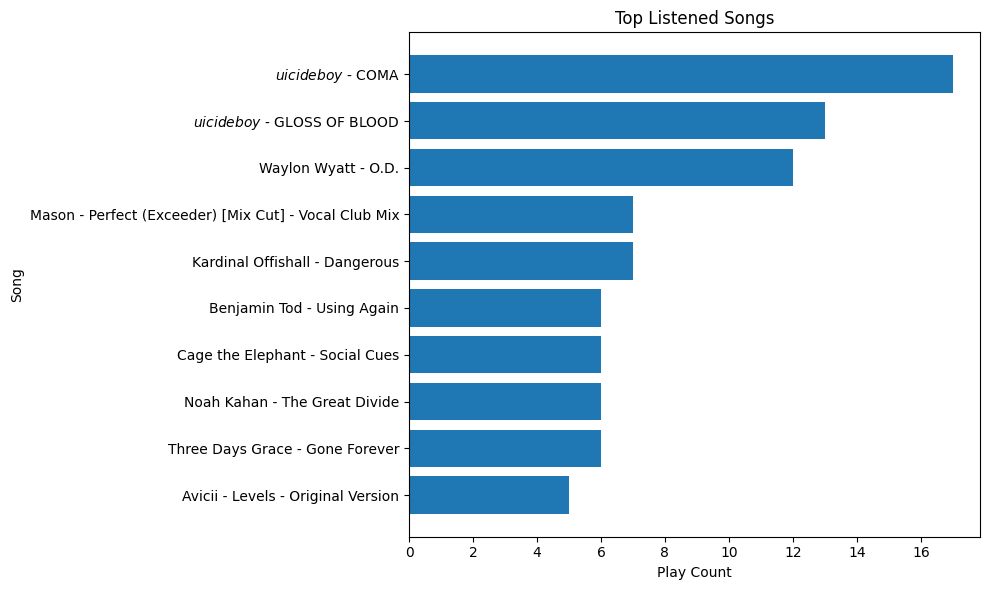

In [153]:
import matplotlib.pyplot as plt

top_songs = clean_df.sort_values("count", ascending=False).head(10).copy()
top_songs["label"] = top_songs["artist"] + " - " + top_songs["track"]

plt.figure(figsize=(10, 6))
plt.barh(top_songs["label"][::-1], top_songs["count"][::-1])
plt.xlabel("Play Count")
plt.ylabel("Song")
plt.title("Top Listened Songs")
plt.tight_layout()
plt.show()

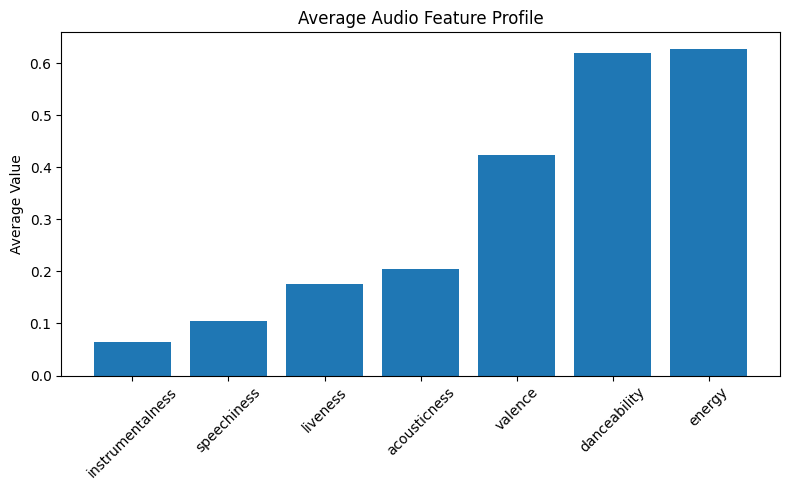

In [154]:
profile_features = [
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "liveness", "speechiness"
]

avg_profile = clean_df[profile_features].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(avg_profile.index, avg_profile.values)
plt.ylabel("Average Value")
plt.title("Average Audio Feature Profile")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

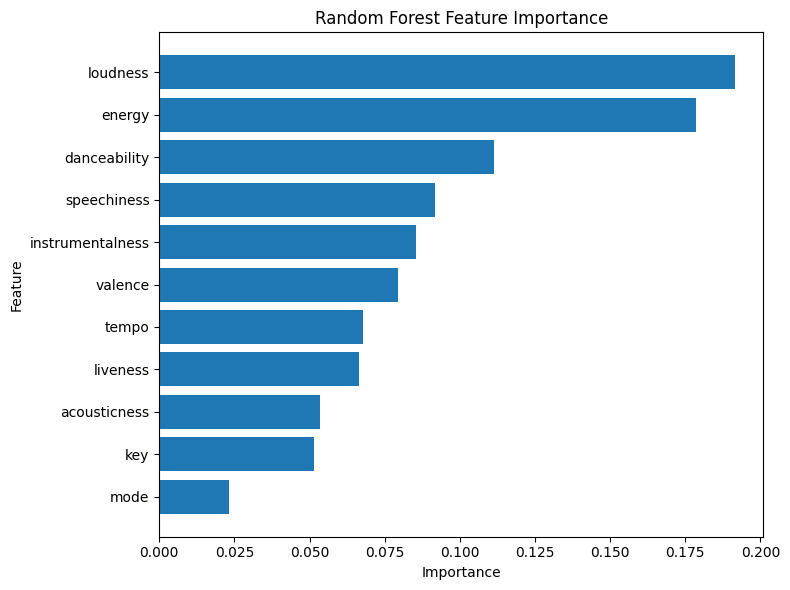

In [166]:
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(importance.index, importance.values)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

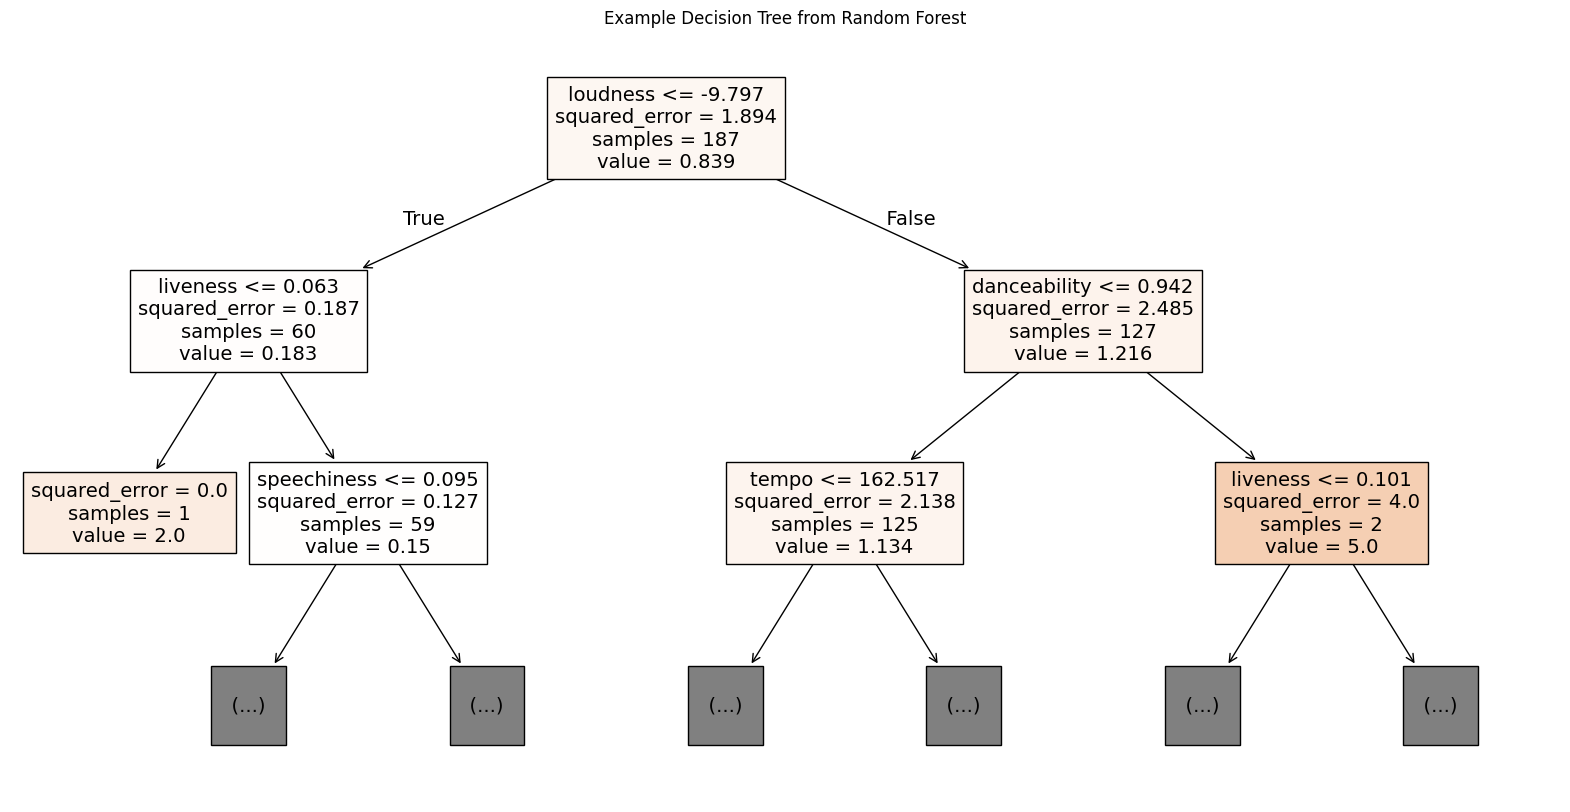

In [167]:
tree = model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=feature_cols,
    class_names=["Not Liked", "Liked"],
    filled=True,
    max_depth=2   # limit depth so the graphic is readable
)

plt.title("Example Decision Tree from Random Forest")
plt.savefig("tree.png")
plt.show()